In this notebook, we consider the results for the damped harmic oscillator with noise.

In [76]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import math
import scipy
import scipy.linalg
import gaussian_crossings.utils as utils
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process
from matplotlib.colors import LogNorm, TwoSlopeNorm
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

In [70]:
# crossing_type = "upcrossing"  
# crossing_type = "downcrossing"
crossing_type = "crossing"
ModelClass = formula.GaussianUpCrossings

mean_rate_method = f"{crossing_type}_mean_rate"
fano_method = f"{crossing_type}_fano_factor_CLT"

In [71]:
# Set simulation parameters.
T = 20.0    # Total simulation time (e.g., 10 time units)
omega0 = math.sqrt(10.0)                   # Fundamental frequency
temp = 10.0                     # Temperature (similar to sigma ** 2)
sigma = math.sqrt(temp) / omega0  # Standard deviation of the process

In [72]:
num_points_zeta = 100
zeta = torch.linspace(0.5, 1.0, num_points_zeta)

num_points_psi = 100
psi = torch.linspace(0.0, 2.0, num_points_psi)

mean_rates = torch.zeros(num_points_zeta, num_points_psi)
fano_factors = torch.zeros(num_points_zeta, num_points_psi)

In [73]:
for i in range(num_points_zeta):
    for j in range(num_points_psi):
        # u is given by psi[j]*sigma, and tau_e depends on zeta[i]
        u = psi[j] * sigma
        model = ModelClass(r_func=process.r_damped_harmonic_oscillator_noise, u=u, temp=temp, zeta=zeta[i].item(), omega0=omega0)
        mean_rates[i, j] = getattr(model, mean_rate_method)()
        fano_factors[i, j] = getattr(model, fano_method)(epsilon_left=1e-5, epsilon_right=1e-5)

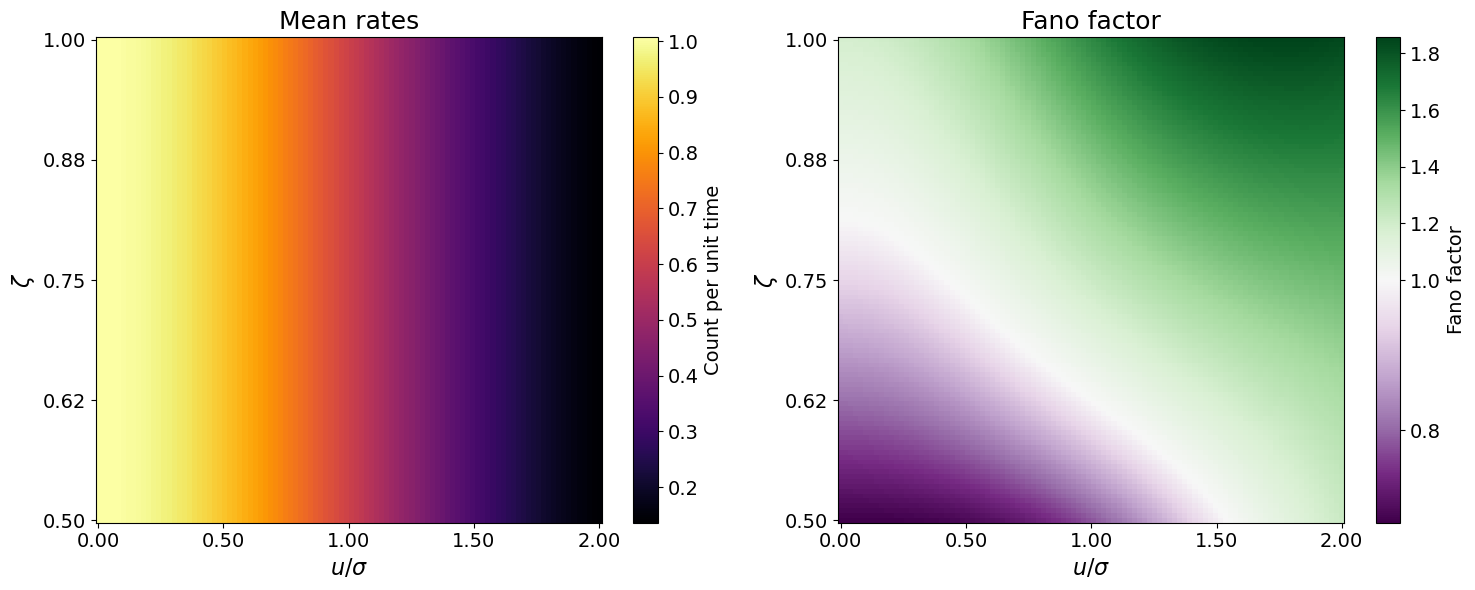

In [77]:
# Convert computed tensors to NumPy arrays for plotting
mean_rates_np = mean_rates.numpy()
fano_factors_np = fano_factors.numpy()
psi_np = psi.numpy()
zeta_np = zeta.numpy()

# -----------------------
# 4. Plotting using pcolormesh with the formal grid
# -----------------------
# Plotting parameters
cmap_mean = 'inferno'
cmap_fano = 'PRGn'
label_fontsize = 16
tick_fontsize = 14
title_fontsize = 18
cbar_labelsize = 14

# Define the number of ticks for the axes independently of the data spacing.
num_ticks = 5
x_ticks = np.linspace(psi_np.min(), psi_np.max(), num_ticks)
y_ticks = np.linspace(zeta_np.min(), zeta_np.max(), num_ticks)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---- Left subplot: Mean Rates (Keep as before) ----
pc0 = axes[0].pcolormesh(psi_np, zeta_np, mean_rates_np, shading='auto',
                         cmap=cmap_mean)
cbar0 = fig.colorbar(pc0, ax=axes[0])
cbar0.set_label("Count per unit time", fontsize=cbar_labelsize)
cbar0.ax.tick_params(labelsize=tick_fontsize)
axes[0].set_xlabel(r'$u/\sigma$', fontsize=label_fontsize)
axes[0].set_ylabel(r'$\zeta$', fontsize=label_fontsize)
axes[0].set_title('Mean rates', fontsize=title_fontsize)
axes[0].set_xticks(x_ticks)
axes[0].set_yticks(y_ticks)
axes[0].set_xticklabels([f"{val:.2f}" for val in x_ticks], fontsize=tick_fontsize)
axes[0].set_yticklabels([f"{val:.2f}" for val in y_ticks], fontsize=tick_fontsize)


# ---- Right subplot: Fano Factors on LINEAR Scale with Divergence at 1 ----

# --- Normalization ---
# Get min/max of the original Fano factor data
vmin_fano = fano_factors_np.min()
vmax_fano = fano_factors_np.max()

# Create the TwoSlopeNorm centered at 1
# This normalizer works directly on the linear Fano factor values
norm_fano = mcolors.TwoSlopeNorm(vmin=vmin_fano, vcenter=1, vmax=vmax_fano)

# --- Plotting ---
# Plot the ORIGINAL fano_factors_np data
pc1 = axes[1].pcolormesh(psi_np, zeta_np, fano_factors_np, shading='auto',
                         cmap=cmap_fano,  # Use the chosen diverging map
                         norm=norm_fano)  # Use the TwoSlopeNorm

# --- Colorbar ---
cbar1 = fig.colorbar(pc1, ax=axes[1])
cbar1.set_label("Fano factor", fontsize=cbar_labelsize)
cbar1.ax.tick_params(labelsize=tick_fontsize)
# No special tick formatter is needed now, as the scale is linear
# The colorbar will automatically show ticks like 0.5, 1.0, 1.5, 2.0 etc.

# --- Axes and Titles ---
axes[1].set_xlabel(r'$u/\sigma$', fontsize=label_fontsize)
axes[1].set_ylabel(r'$\zeta$', fontsize=label_fontsize)
axes[1].set_title('Fano factor', fontsize=title_fontsize)
axes[1].set_xticks(x_ticks)
axes[1].set_yticks(y_ticks)
axes[1].set_xticklabels([f"{val:.2f}" for val in x_ticks], fontsize=tick_fontsize)
axes[1].set_yticklabels([f"{val:.2f}" for val in y_ticks], fontsize=tick_fontsize)

# --- Figure Title ---
# Assuming crossing_type is defined
# fig.suptitle(f"{crossing_type} damped harmonic oscillator", fontsize=title_fontsize)

plt.tight_layout()
plt.show()

